# Transferencia de Aprendizaje (Transfer Learning) con MobileNetV2

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de esta sesión es comprender e implementar la técnica de **Transferencia de Aprendizaje (Transfer Learning)**. Reutilizaremos los filtros y características espaciales previamente aprendidos por la red eficiente **MobileNetV2** (entrenada en ImageNet), congelando su base convolucional y entrenando únicamente una nueva capa de salida personalizada para clasificar un dataset local de perros y gatos.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Explicar los fundamentos, ventajas y casos de uso prácticos de la Transferencia de Aprendizaje frente al entrenamiento desde cero.
2. Cargar un modelo convolucional preentrenado de Keras (`MobileNetV2`) excluyendo sus capas superiores de clasificación final.
3. Congelar los pesos de las capas convolucionales base para evitar que se actualicen durante el entrenamiento.
4. Aplicar técnicas de **Aumento de Datos (Data Augmentation)** mediante Keras para expandir artificialmente el dataset de entrenamiento y mitigar el sobreajuste.
5. Entrenar y evaluar el modelo híbrido resultante, analizando el comportamiento de las curvas de precisión y error.

## Terminología clave (Microglosario)

*   **Transferencia de Aprendizaje (Transfer Learning):** Metodología en aprendizaje profundo que consiste en tomar un modelo que ya ha sido entrenado en un gran dominio general y adaptarlo a un nuevo problema específico con menos datos y recursos computacionales. *Como un carpintero especialista en roble que aprende a trabajar pino: no necesita reaprender a usar el serrucho ni las técnicas base, solo ajusta su criterio al material nuevo.*
*   **MobileNetV2:** Red neuronal convolucional profunda ligera y altamente optimizada para dispositivos embebidos y móviles, caracterizada por convoluciones separables en profundidad y bloques residuales invertidos. *Como un motor de Fórmula 1 rediseñado para un auto de ciudad: conserva la potencia esencial pero con un consumo y tamaño aptos para hardware limitado.*
*   **Congelamiento de Capas (Freezing):** Técnica para bloquear los pesos de ciertas capas de un modelo preentrenado, haciendo que sus parámetros permanezcan constantes e inalterables durante la fase de retropropagación del entrenamiento. *Como renovar solo el último piso de un edificio sin tocar los cimientos ni la estructura: se preserva lo que ya funciona y se adapta solo lo que necesita cambiar.*
*   **Aumento de Datos (Data Augmentation):** Estrategia para generar variaciones aleatorias pero lógicas en las imágenes de entrada (como rotaciones, zooms, recortes) con el fin de robustecer la generalización de la red. *Como fotografiar el mismo objeto desde veinte ángulos distintos para que quien aprende lo reconozca sin importar desde dónde lo miren.*

## 1. Configuración de Librerías y Dependencias

Importemos las librerías necesarias de TensorFlow/Keras para cargar el modelo preentrenado, preparar los generadores de imágenes y configurar las transformaciones del dataset.

In [1]:
print('✦ Instalando dependencias necesarias en el sistema...')
%pip install -q tensorflow matplotlib numpy pillow
print('✓ Librerías instaladas con éxito.')

✦ Instalando dependencias necesarias en el sistema...
Note: you may need to restart the kernel to use updated packages.
✓ Librerías instaladas con éxito.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
print('✦ Cargando librerías y configurando TensorFlow...')
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import shutil
import os
print('✓ Entorno listo para Transfer Learning.')

✦ Cargando librerías y configurando TensorFlow...
✓ Entorno listo para Transfer Learning.


## 2. Preparación y Extracción del Dataset Local

Para realizar este laboratorio de forma local o en la nube, descomprimiremos los archivos zip `perros.zip` y `gatos.zip` colocados en la carpeta `datos/` (o en la raíz del entorno), unificándolos bajo un directorio estructurado llamado `dataset/`.

In [4]:
print('✦ Configurando carpetas para el dataset local...')
os.makedirs('dataset', exist_ok=True)

# Descomprimimos los zips locales si existen en la raíz o en datos/
for zip_name, class_name in [('perros.zip', 'perro'), ('gatos.zip', 'gato')]:
    zip_path = zip_name
    if not os.path.exists(zip_path):
        zip_path = os.path.join('datos', zip_name)
        
    if os.path.exists(zip_path):
        print(f'  ✦ Descomprimiendo {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('dataset')
        
        # Si el zip crea una carpeta anidada de nombre original, la renombramos a class_name
        orig_dir = zip_name.replace('.zip', '') # 'perros' o 'gatos'
        orig_path = os.path.join('dataset', orig_dir)
        dest_path = os.path.join('dataset', class_name)
        
        if os.path.exists(orig_path):
            if os.path.exists(dest_path):
                shutil.rmtree(dest_path)
            os.rename(orig_path, dest_path)
            print(f'  ✓ Clase "{class_name}" lista en {dest_path}.')
        else:
            print(f'  ✓ Clase "{class_name}" extraída correctamente.')
    else:
        print(f'  ⚠ Archivo {zip_name} no encontrado en la raíz ni en datos/.')

print('\n✓ Dataset estructurado con éxito.')

✦ Configurando carpetas para el dataset local...
  ✦ Descomprimiendo datos\perros.zip...
  ✓ Clase "perro" lista en dataset\perro.
  ✦ Descomprimiendo datos\gatos.zip...
  ✓ Clase "gato" lista en dataset\gato.

✓ Dataset estructurado con éxito.


## 3. Configuración de Aumento de Datos y Generadores

Para ampliar la robustez del modelo, utilizaremos `ImageDataGenerator` para aplicar transformaciones de aumento de datos aleatorias al conjunto de entrenamiento y normalizar los valores al rango $[0, 1]$.

In [5]:
print('✦ Configurando ImageDataGenerator con Data Augmentation...')

# Definimos las transformaciones para el dataset, reservando el 20% para validación
datagen = ImageDataGenerator(
    rescale=1. / 255.0,            # Normalización de píxeles de [0, 255] a [0.0, 1.0]
    rotation_range=10,             # Rotaciones aleatorias de ±10 grados
    width_shift_range=0.15,        # Desplazamientos horizontales de ±15%
    height_shift_range=0.15,       # Desplazamientos verticales de ±15%
    shear_range=5,                 # Distorsiones de corte (shear)
    zoom_range=[0.7, 1.3],         # Zooms variables entre 70% y 130%
    validation_split=0.2           # Split del 20% para validación
)

print('✦ Cargando lotes de entrenamiento...')
data_gen_entrenamiento = datagen.flow_from_directory(
    'dataset',
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
    subset='training'
)

print('✦ Cargando lotes de validación...')
data_gen_pruebas = datagen.flow_from_directory(
    'dataset',
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
    subset='validation'
)

print('\n✓ Generadores y lotes listos.')

✦ Configurando ImageDataGenerator con Data Augmentation...
✦ Cargando lotes de entrenamiento...
Found 625 images belonging to 2 classes.
✦ Cargando lotes de validación...
Found 155 images belonging to 2 classes.

✓ Generadores y lotes listos.


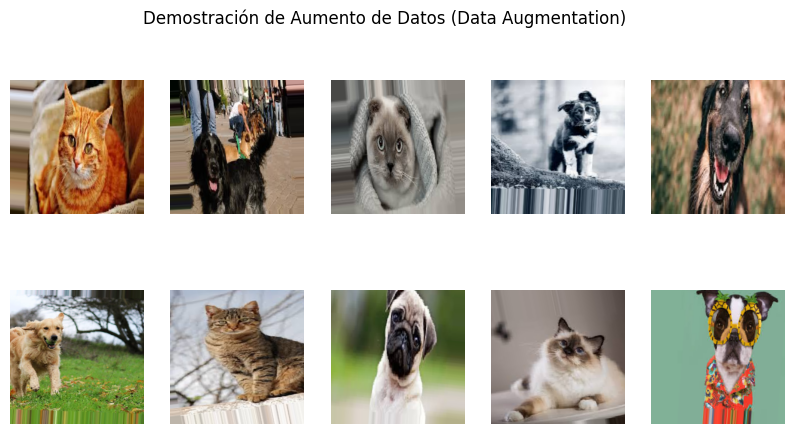

In [6]:
# Tomamos un lote del generador para visualizar los aumentos aplicados
for imagenes, etiquetas in data_gen_entrenamiento:
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imagenes[i])
        plt.axis('off')
    break
plt.suptitle('Demostración de Aumento de Datos (Data Augmentation)')
plt.show()

## ✦ Antes de codificar: Transfer Learning en dos fases

Vamos a entender el mecanismo antes de ejecutarlo. El entrenamiento por transferencia funciona en dos fases bien diferenciadas:

**Fase 1 — Extracción de características (lo que vamos a hacer hoy):**

```
MobileNetV2 completo (preentrenado en ImageNet)
├── ~150 capas convolucionales  ←  CONGELADAS (trainable = False)
│    Ya saben detectar bordes, texturas, formas y patrones complejos.
└── Clasificador de 1000 clases  ←  DESCARTADO (include_top = False)

Agregamos encima un clasificador nuevo:
    GlobalAveragePooling2D()   ←  va a aprender
    Dropout(0.2)               ←  va a aprender
    Dense(2, softmax)          ←  va a aprender: "¿es perro o gato?"
```

**¿Por qué congelar las capas base?** Porque ya saben hacer su trabajo. Si las dejamos libres con pocos datos, las sobreescribiremos con ruido y perderemos el conocimiento construido sobre millones de imágenes.

**Fase 2 — Fine-tuning (para sesiones futuras):** Se descongelan las últimas capas de MobileNetV2 y se re-entrenan con una tasa de aprendizaje muy baja para afinarlas al dominio específico.

## 4. Carga de MobileNetV2 y Congelamiento de Capas

Cargaremos la red convolucional **MobileNetV2** preentrenada en ImageNet omitiendo su clasificador superior (`include_top=False`). Luego, congelaremos todas las capas base convolucionales para preservar sus filtros visuales.

In [7]:
print('✦ Descargando y cargando MobileNetV2 preentrenado en ImageNet...')

# Cargamos el modelo convolucional base
modelo_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,           # Excluye la capa final totalmente conectada de ImageNet
    weights='imagenet'           # Carga los pesos preentrenados oficiales
)

# Congelamos los pesos de la red convolucional base
modelo_base.trainable = False
print('✓ Capas convolucionales de MobileNetV2 congeladas con éxito.')

✦ Descargando y cargando MobileNetV2 preentrenado en ImageNet...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✓ Capas convolucionales de MobileNetV2 congeladas con éxito.


## 5. Ensamblaje y Compilación del Modelo Híbrido

Construiremos el nuevo modelo conectando las capas convolucionales base congeladas a un promedio espacial bidimensional (`GlobalAveragePooling2D`) y a una capa densa final de salida softmax para las dos clases perro y gato.

In [8]:
print('✦ Ensamblando la arquitectura híbrida para Transfer Learning...')

modelo = Sequential([
    modelo_base,                  # Red base convolucional preentrenada y congelada
    GlobalAveragePooling2D(),     # Reduce las dimensiones espaciales promediándolas
    Dropout(0.2),                 # Capa de regularización para evitar el sobreajuste
    Dense(2, activation='softmax') # Clasificador de dos neuronas de salida para las clases
])

print('✦ Compilando el modelo con optimizador Adam a baja tasa de aprendizaje...')
modelo.compile(
    optimizer=Adam(learning_rate=0.0001), # Tasa reducida para no desestabilizar los pesos
    loss='categorical_crossentropy',      # Pérdida multiclase estándar
    metrics=['accuracy']                  # Exactitud como métrica de evaluación
)

print('✓ Modelo compilado con éxito.\n')
modelo.summary()

✦ Ensamblando la arquitectura híbrida para Transfer Learning...
✦ Compilando el modelo con optimizador Adam a baja tasa de aprendizaje...
✓ Modelo compilado con éxito.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Entrenamiento del Modelo Híbrido

Procederemos a entrenar únicamente las nuevas capas densas de salida por un total de 5 épocas, observando la evolución del rendimiento.

In [9]:
EPOCAS = 5

print(f'✦ Iniciando entrenamiento de Transfer Learning por {EPOCAS} épocas...')
historial = modelo.fit(
    data_gen_entrenamiento,
    epochs=EPOCAS,
    validation_data=data_gen_pruebas
)

print('\n✓ Entrenamiento finalizado con éxito.')

✦ Iniciando entrenamiento de Transfer Learning por 5 épocas...
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6912 - loss: 0.6225 - val_accuracy: 0.7484 - val_loss: 0.5113
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 731ms/step - accuracy: 0.7376 - loss: 0.5267 - val_accuracy: 0.7742 - val_loss: 0.4388
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 732ms/step - accuracy: 0.7808 - loss: 0.4619 - val_accuracy: 0.8258 - val_loss: 0.3962
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 732ms/step - accuracy: 0.8096 - loss: 0.4103 - val_accuracy: 0.8581 - val_loss: 0.3508
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 732ms/step - accuracy: 0.8352 - loss: 0.3566 - val_accuracy: 0.8645 - val_loss: 0.2959

✓ Entrenamiento finalizado con éxito.


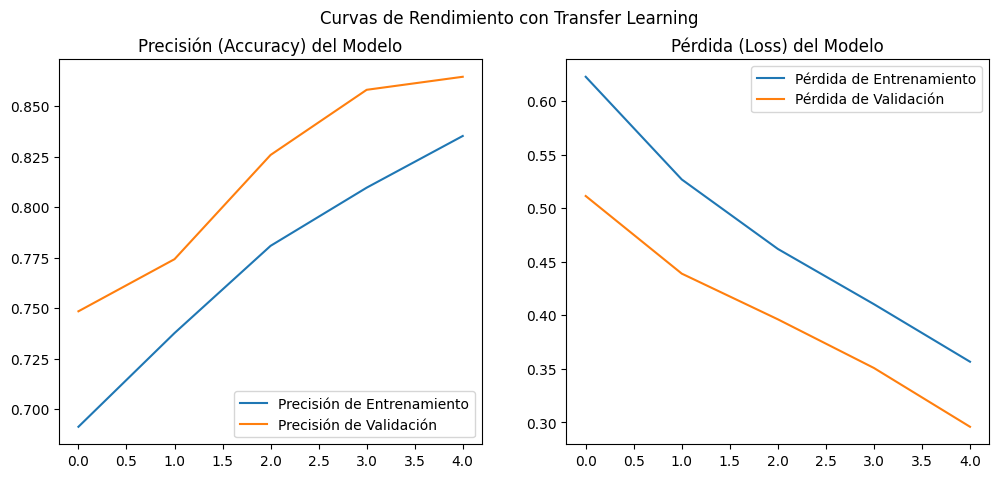

In [10]:
# Extraemos cada métrica del historial de entrenamiento en una variable con nombre claro
precision_entrenamiento = historial.history['accuracy']
precision_validacion = historial.history['val_accuracy']
perdida_entrenamiento = historial.history['loss']
perdida_validacion = historial.history['val_loss']
epocas_rango = range(EPOCAS)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas_rango, precision_entrenamiento, label='Precisión de Entrenamiento')
plt.plot(epocas_rango, precision_validacion, label='Precisión de Validación')
plt.title('Precisión (Accuracy) del Modelo')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epocas_rango, perdida_entrenamiento, label='Pérdida de Entrenamiento')
plt.plot(epocas_rango, perdida_validacion, label='Pérdida de Validación')
plt.title('Pérdida (Loss) del Modelo')
plt.legend(loc='upper right')

plt.suptitle('Curvas de Rendimiento con Transfer Learning')
plt.show()

## Consigna de Lectura e Interpretación

Analicen detenidamente las curvas de precisión y error obtenidas. 
- ¿Qué exactitud se alcanzó desde la primera época de entrenamiento?

Al completar la 1 época alcanza una precisión del 77% y la de entrenamiento un 74%

- ¿A qué atribuyen que el rendimiento escale tan rápidamente a valores tan elevados en comparación con entrenar una red de convolución profunda desde cero?

Una red con Transfer Learning ya ha sido entrenada previamente con millones de imágenes genéricas. Por otro lado, en las primeras capas convolucionales, la red ya sabe reconocer de inmediato elementos visuales esenciales como bordes, líneas, texturas, colores y formas geométricas complejas. Una red entrenada desde cero requiere de decenas de épocas solo para aprender a identificar qué es una línea horizontal o una curva. Y también, nos encontramos ante menor número de parámetros que optimizar ya que al aplicar esta técnica, habitualmente se "congelan" las capas convolucionales (las que extraen los rasgos de la imagen) y solo se entrena la capa de clasificación final (la "cabeza" de la red) para adaptarla a tu problema específico. Al tener que ajustar una cantidad mínima de conexiones, el modelo converge de forma casi inmediata.


## Cierre de Laboratorio

Comprobaron y asimilaron de forma empírica la formidable técnica de **Transferencia de Aprendizaje (Transfer Learning)**, entrenando un modelo híbrido basado en **MobileNetV2** para un dataset de perros y gatos.

En la siguiente sesión daremos un salto decisivo hacia el estado del arte de la inteligencia artificial visual y utilizaremos pipelines preentrenados del ecosistema oficial de **Hugging Face** para desplegar Vision Transformers (ViT), modelos Zero-Shot (CLIP) y detectores con localización espacial de objetos (DETR).